<a href="https://colab.research.google.com/github/Blecyrajan/Dissertation/blob/main/BrainTumor_CNN_ViT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Downloading dataset




In [12]:
import kagglehub
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.


# 2. Install required libraries

In [13]:
!pip install torch torchvision opencv-python matplotlib tqdm scikit-learn

## 3. Import required libraries

In [14]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


# 3. Dataset path






In [15]:
DATASET_PATH = "/kaggle/input/brain-tumor-mri-dataset"

In [16]:
os.listdir(DATASET_PATH)

['Training', 'Testing']

In [17]:
TRAIN_PATH = os.path.join(DATASET_PATH, "Training")
TEST_PATH  = os.path.join(DATASET_PATH, "Testing")

print("Train folders:", os.listdir(TRAIN_PATH))
print("Test folders:", os.listdir(TEST_PATH))

Train folders: ['pituitary', 'notumor', 'meningioma', 'glioma']
Test folders: ['pituitary', 'notumor', 'meningioma', 'glioma']


In [18]:
print("Dataset root:", os.listdir(DATASET_PATH))
print("\nTraining classes:", os.listdir(os.path.join(DATASET_PATH, "Training")))
print("\nTesting classes:", os.listdir(os.path.join(DATASET_PATH, "Testing")))


Dataset root: ['Training', 'Testing']

Training classes: ['pituitary', 'notumor', 'meningioma', 'glioma']

Testing classes: ['pituitary', 'notumor', 'meningioma', 'glioma']


# 4. Sample brain MRI

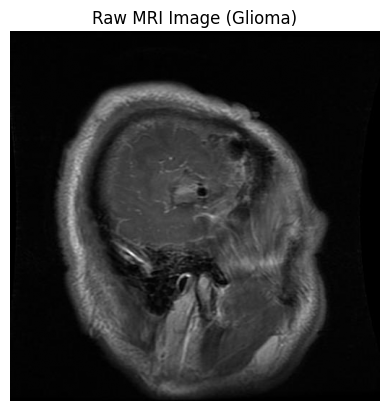

In [19]:
sample_class = "glioma"
sample_image = os.listdir(os.path.join(TRAIN_PATH, sample_class))[0]

img_path = os.path.join(TRAIN_PATH, sample_class, sample_image)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title("Raw MRI Image (Glioma)")
plt.axis("off")
plt.show()


# DEFINE OUTPUT DIRECTORY

In [20]:
PROCESSED_ROOT = "/content/Processed_Dataset"

PROCESSED_TRAIN = os.path.join(PROCESSED_ROOT, "Training")
PROCESSED_TEST  = os.path.join(PROCESSED_ROOT, "Testing")

os.makedirs(PROCESSED_TRAIN, exist_ok=True)
os.makedirs(PROCESSED_TEST, exist_ok=True)

print("Processed folders created")


Processed folders created


# PROCESS & SAVE IMAGES

In [21]:
def preprocess_and_save(input_root, output_root):
    classes = ["glioma", "meningioma", "pituitary", "notumor"]

    for cls in classes:
        input_cls_dir = os.path.join(input_root, cls)
        output_cls_dir = os.path.join(output_root, cls)

        os.makedirs(output_cls_dir, exist_ok=True)

        for img_name in os.listdir(input_cls_dir):
            img_path = os.path.join(input_cls_dir, img_name)

            img = preprocess_image(img_path)

            # convert back to uint8 for saving
            img_uint8 = (img * 255).astype(np.uint8)

            save_path = os.path.join(output_cls_dir, img_name)
            cv2.imwrite(save_path, img_uint8)

        print(f"Saved preprocessed images for class: {cls}")


# PREPROCESS & SAVE TRAINING DATA

In [24]:
preprocess_and_save(TRAIN_PATH, PROCESSED_TRAIN)

Saved preprocessed images for class: glioma
Saved preprocessed images for class: meningioma
Saved preprocessed images for class: pituitary
Saved preprocessed images for class: notumor


In [23]:
IMG_SIZE = 224

def preprocess_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) #resize to 224 x 224
    img = img / 255.0 #pixels are normalized

    # convert grayscale -> 3 channel
    img = np.stack([img, img, img], axis=-1)

    return img

# PREPROCESS & SAVE TESTING DATA

In [25]:
preprocess_and_save(TEST_PATH, PROCESSED_TEST)

Saved preprocessed images for class: glioma
Saved preprocessed images for class: meningioma
Saved preprocessed images for class: pituitary
Saved preprocessed images for class: notumor


# VERIFY SAVED FILES

In [26]:
print("Processed Training folders:", os.listdir(PROCESSED_TRAIN))
print("Sample images in glioma:",
      os.listdir(os.path.join(PROCESSED_TRAIN, "glioma"))[:5])


Processed Training folders: ['notumor', 'meningioma', 'pituitary', 'glioma']
Sample images in glioma: ['Tr-gl_1016.jpg', 'Tr-gl_1297.jpg', 'Tr-gl_0352.jpg', 'Tr-gl_0091.jpg', 'Tr-gl_0097.jpg']


# VISUAL CHECK (RAW vs SAVED PROCESSED)

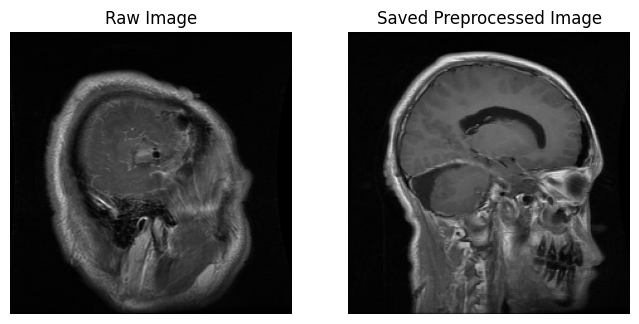

In [27]:
raw_img = cv2.imread(
    os.path.join(TRAIN_PATH, "glioma", os.listdir(os.path.join(TRAIN_PATH, "glioma"))[0]),
    cv2.IMREAD_GRAYSCALE
)

processed_img = cv2.imread(
    os.path.join(PROCESSED_TRAIN, "glioma", os.listdir(os.path.join(PROCESSED_TRAIN, "glioma"))[0]),
    cv2.IMREAD_GRAYSCALE
)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Raw Image")
plt.imshow(raw_img, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Saved Preprocessed Image")
plt.imshow(processed_img, cmap="gray")
plt.axis("off")

plt.show()


# UPDATE DATASET CLASS TO USE PROCESSED DATA

In [28]:
class MRIDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []
        self.class_map = {
            "glioma": 0,
            "meningioma": 1,
            "pituitary": 2,
            "notumor": 3
        }

        for cls in self.class_map:
            cls_dir = os.path.join(root_dir, cls)
            for img_name in os.listdir(cls_dir):
                self.samples.append(
                    (os.path.join(cls_dir, img_name), self.class_map[cls])
                )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        img = cv2.imread(img_path)
        img = img / 255.0
        img = torch.tensor(img).permute(2, 0, 1).float()

        return img, label


In [29]:
train_dataset = MRIDataset(PROCESSED_TRAIN)
test_dataset  = MRIDataset(PROCESSED_TEST)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("Train batches ready:", len(train_loader))


Train batches ready: 714
